In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [14]:
nifty = yf.download("^NSEI", start="2018-01-01", progress=False)
nifty = nifty.reset_index().sort_values("Date").set_index("Date")
nifty["nifty_ret"] = nifty["Close"].pct_change()

banknifty = yf.download("^NSEBANK", start="2018-01-01", progress=False)
banknifty = banknifty.reset_index().sort_values("Date").set_index("Date")
banknifty["bank_ret"] = banknifty["Close"].pct_change()

market = pd.merge(
    nifty[["Close", "nifty_ret"]],
    banknifty[["Close", "bank_ret"]],
    left_index=True,
    right_index=True,
    how="inner"
)

market.columns = ["nifty_close", "nifty_ret", "bank_close", "bank_ret"]

market.head()

,nifty_close,nifty_ret,bank_close,bank_ret
Date,,,,
2018-01-02,10442.200195,NaN,25337.955078,0.000796
2018-01-03,10443.200195,0.000096,25318.304688,-0.000776
2018-01-04,10504.799805,0.005899,25462.302734,0.005688
2018-01-05,10558.849609,0.005145,25601.552734,0.005469
2018-01-08,10623.599609,0.006132,25675.800781,0.002900


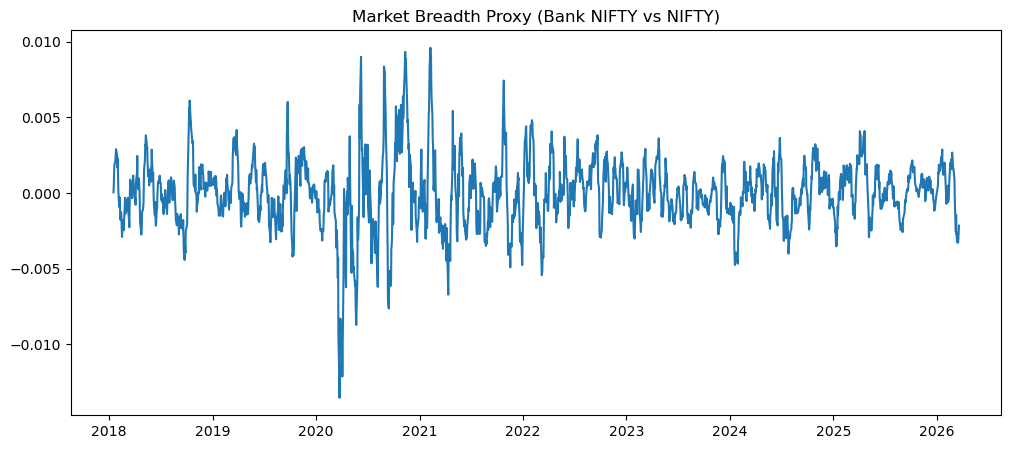

In [15]:
market["relative_strength"] = market["bank_ret"] - market["nifty_ret"]
market["breadth_signal"] = market["relative_strength"].rolling(10).mean()

plt.figure(figsize=(12,5))
plt.plot(market.index, market["breadth_signal"])
plt.title("Market Breadth Proxy (Bank NIFTY vs NIFTY)")
plt.show()

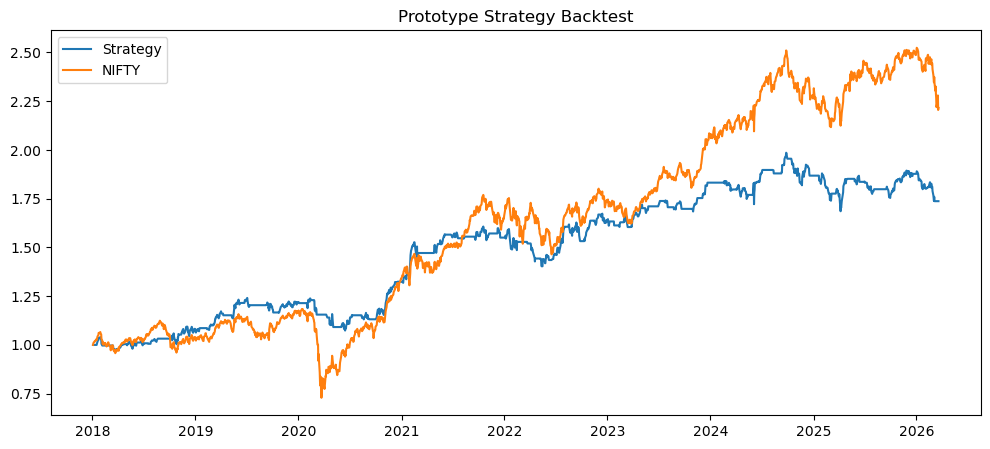

In [18]:
market["position"] = np.where(market["breadth_signal"] > 0, 1, 0)

market["strategy_ret"] = market["position"].shift(1) * market["nifty_ret"]

market["equity_curve"] = (1 + market["strategy_ret"]).cumprod()

plt.figure(figsize=(12,5))
plt.plot(market.index, market["equity_curve"], label="Strategy")
plt.plot(market.index, (1 + market["nifty_ret"]).cumprod(), label="NIFTY")
plt.legend()
plt.title("Prototype Strategy Backtest")
plt.show()